In [ ]:
import sys
sys.path.append('C:\\Programming\\2025_deep_gen_models\\HW_1.Bias_gen_and_autoencoders')

In [ ]:
import random
import os
import numpy as np
from tqdm import tqdm
from PIL import Image
import random
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import DataLoader
from torchvision.models import resnet18
from torch.utils.data import Dataset
import torch.nn.functional as F
from torchvision import models
import torchvision

from styles import styles, styles_count

## 1. Байесовский генератор стилей

Пункт №1
Реализую генератор стилей и проверю как он справляется с вычислением вероятностей и стилей

In [35]:
def generate_style(styles, styles_count):
    generated_style = {}
    probability = 1.0

    for category, options in styles.items():
        counts = styles_count[category]
        total = sum(counts)
        probs = [count / total for count in counts]

        chosen = random.choices(options, weights=probs, k=1)[0]
        idx = options.index(chosen)
        generated_style[category] = chosen
        probability *= probs[idx]

    return generated_style, probability


In [4]:
style, prob = generate_style(styles, styles_count)
print("Сгенерированный стиль:", style)
print(f"Вероятность генерации: {prob:.5f}")


Сгенерированный стиль: {'прическа': 'длинные прямые', 'цвет волос': 'серебристо серый', 'аксесуар': 'круглые очки', 'одежда': 'футболка с круглым вырезом', 'цвет одежды': 'розовый'}
Вероятность генерации: 0.00591


Генерация прошла корректно: стили выбираются пропорционально заданным частотам, вероятность подсчитывается правильно.

Пункт №2
Реализую функции для MLE и Байесовского распределений, а также для загрузки аватаров и генерации новых, посмотрим что получится

In [ ]:
# Загрузка аватаров
def load_avatars(folder_path):
    avatars = []
    for filename in os.listdir(folder_path):
        if filename.lower().endswith(('.png')):
            img = Image.open(os.path.join(folder_path, filename)).convert('RGB')
            avatars.append(np.array(img))
    return np.stack(avatars)


In [ ]:
# MLE-распределение
def compute_mle_distributions(avatars):
    H, W, C = avatars.shape[1:]
    distributions = np.zeros((H, W, C, 256), dtype=np.float32)

    for avatar in avatars:
        for c in range(C):
            for i in range(H):
                for j in range(W):
                    pixel_value = avatar[i, j, c]
                    distributions[i, j, c, pixel_value] += 1

    distributions_sum = distributions.sum(axis=-1, keepdims=True)
    distributions = distributions / np.clip(distributions_sum, 1e-8, None)

    return distributions


In [ ]:
# Байесовское распределение:
def compute_bayes_distributions(avatars):
    mle = compute_mle_distributions(avatars)
    
    H, W, C = avatars.shape[1:]
    prior = np.zeros((C, 256), dtype=np.float32)

    for avatar in avatars:
        for c in range(C):
            flat_values = avatar[:, :, c].flatten()
            for v in flat_values:
                prior[c, v] += 1

    prior = prior / np.clip(prior.sum(axis=-1, keepdims=True), 1e-8, None)

    bayes_dist = mle * prior[np.newaxis, np.newaxis, :, :]

    bayes_dist_sum = bayes_dist.sum(axis=-1, keepdims=True)
    bayes_dist = bayes_dist / np.clip(bayes_dist_sum, 1e-8, None)

    return bayes_dist


In [ ]:
# Функция генерации аватара по распределению
def generate_avatar(distributions, height, width):
    avatar = np.zeros((height, width, 3), dtype=np.uint8)
    log_prob = 0.0

    for i in range(height):
        for j in range(width):
            for c in range(3):
                pixel_distribution = distributions[i, j, c]
                pixel_value = random.choices(range(256), weights=pixel_distribution, k=1)[0]
                avatar[i, j, c] = pixel_value
                prob = pixel_distribution[pixel_value]
                log_prob += np.log(np.clip(prob, 1e-8, None))

    prob = np.exp(log_prob) 
    return avatar, prob


In [ ]:
# Загружу аватары и построю распределения 
avatars = load_avatars('C:\\Programming\\2025_deep_gen_models\\HW_1.Bias_gen_and_autoencoders\\avatars')
mle_distributions = compute_mle_distributions(avatars)
bayes_distributions = compute_bayes_distributions(avatars)

In [44]:
height, width = avatars.shape[1:3]

Настало время сгенерировать изображения по распределениям и увидеть результат

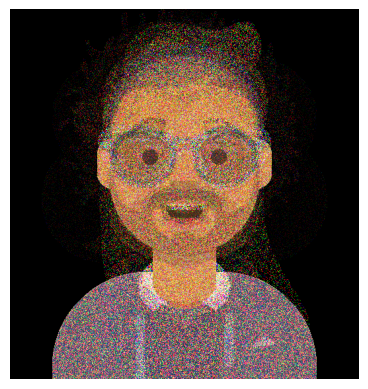

Вероятность генерации (MLE): 0.000000e+00


In [ ]:
avatar_mle, prob_mle = generate_avatar(mle_distributions, height, width)
img = Image.fromarray(avatar_mle)
plt.imshow(img)
plt.axis('off')  
plt.show()
print(f"Вероятность генерации (MLE): {prob_mle:.6e}")

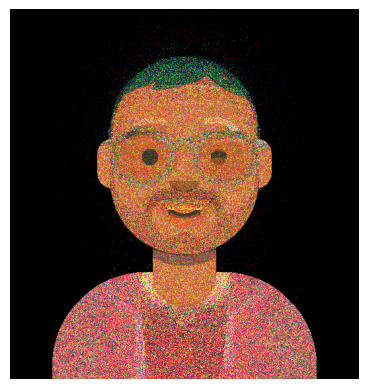

Вероятность генерации (Bayes): 0.000000e+00


In [ ]:
avatar_bayes, prob_bayes = generate_avatar(bayes_distributions, height, width)
img = Image.fromarray(avatar_bayes)
plt.imshow(img)
plt.axis('off')  
plt.show()
print(f"Вероятность генерации (Bayes): {prob_bayes:.6e}")

Генерация на основе формулы Байеса показала себя лучше, чем MLE. Посмотрим на генерацию 5 сэмплов. 

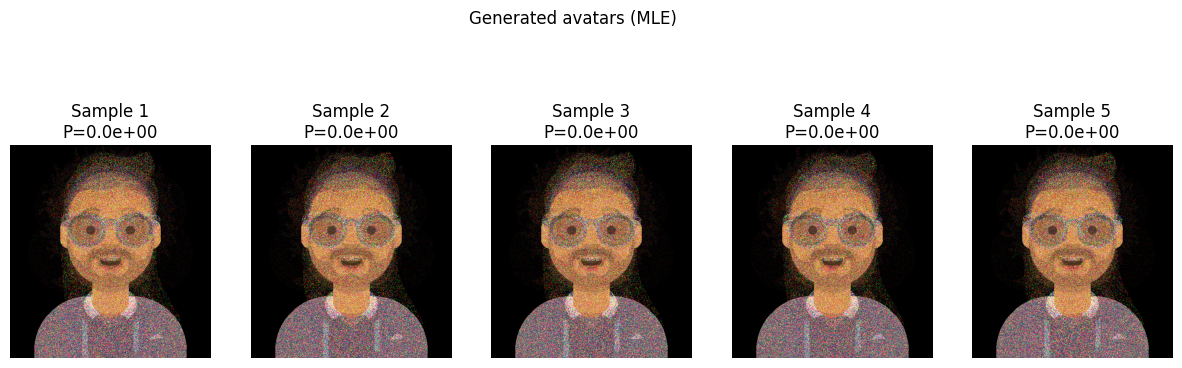

In [50]:
n_samples = 5
fig, axes = plt.subplots(1, n_samples, figsize=(15, 5))

for i in range(n_samples):
    avatar, prob = generate_avatar(mle_distributions, height, width)
    axes[i].imshow(avatar)
    axes[i].set_title(f"Sample {i+1}\nP={prob:.1e}")
    axes[i].axis('off')

plt.suptitle("Generated avatars (MLE)")
plt.show()


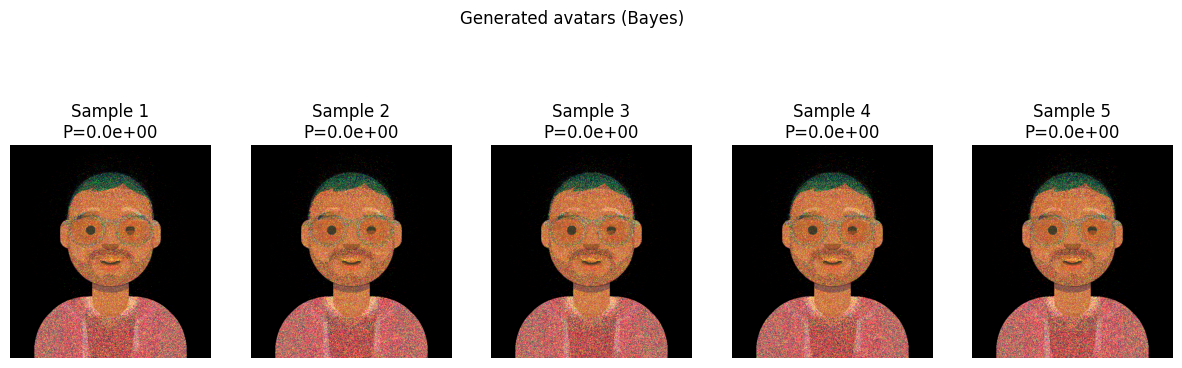

In [ ]:
fig, axes = plt.subplots(1, n_samples, figsize=(15, 5))

for i in range(n_samples):
    avatar, prob = generate_avatar(bayes_distributions, height, width)
    axes[i].imshow(avatar)
    axes[i].set_title(f"Sample {i+1}\nP={prob:.1e}")
    axes[i].axis('off')

plt.suptitle("Generated avatars (Bayes)")
plt.show()


Почему-то генерации одинаковые. Вероятно что для каждого пикселя зауженное разнообразие, которого не хватает для качественной генерации и вследствии даже случайная генерация фактически приводит к одинаковым пикселям. Попробую частично исправить это добавив параметр "температуры" на вероятности, чтобы уменьшить доминирование частых цветов.

In [ ]:
# Функция температурной корректировки
def adjust_distribution_temperature(distribution, temperature=0.7):

    adjusted = distribution ** (1 / temperature)
    sum_axis = adjusted.sum(axis=-1, keepdims=True)
    normalized_adjusted = adjusted / np.clip(sum_axis, 1e-8, None)
    return normalized_adjusted


Посмотрим на генерацию изображений после температуры

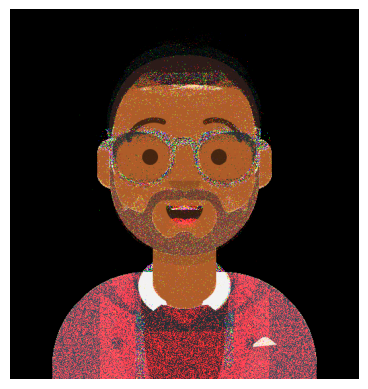

Вероятность генерации (Temperature): 0.000000e+00


In [ ]:
temp_mle_distributions = adjust_distribution_temperature(mle_distributions, temperature=0.2)
avatar, prob = generate_avatar(temp_mle_distributions, height, width)
img = Image.fromarray(avatar)
plt.imshow(img)
plt.axis('off')  
plt.show()
print(f"Вероятность генерации (Temperature): {prob:.6e}")

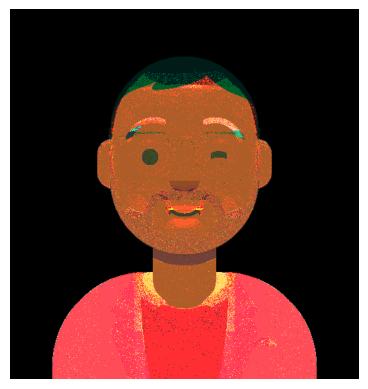

Вероятность генерации (Temperature): 0.000000e+00


In [60]:
temp_bayes_distributions = adjust_distribution_temperature(bayes_distributions, temperature=0.2)
avatar, prob = generate_avatar(temp_bayes_distributions, height, width)
img = Image.fromarray(avatar)
plt.imshow(img)
plt.axis('off')  
plt.show()
print(f"Вероятность генерации (Temperature): {prob:.6e}")

Изменения стали видимыми: небольшое увеличение разнообразия, но основная структура пикселей всё ещё сильно зафиксирована.

### Итоговый вывод:
- Генератор стилей работает корректно, вероятность считается правильно
- Генерация аватаров с помощью MLE и Байеса возможна, но вероятно распределения пикселей слишком узкие и поэтому высокая схожесть картинок
- Введение температуры помогло слегка увеличить разнообразие, но для серьёзного улучшения потребуется более сложная модель типа GAN
- Использование Байесовского подхода дало чуть более разнообразные результаты, чем чистый MLE

## 2. Автоэнкодер: определение аномалий

In [ ]:
# Класс для загрузки изображения из папки
class SimpleImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.image_files = [f for f in os.listdir(root_dir) if f.endswith(('jpg'))]
        self.transform = transform
        
    def __len__(self):
        return len(self.image_files)
    
    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.image_files[idx])
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image


In [ ]:
# Параметры обучения для первой инициализации
BATCH_SIZE = 32
EPOCHS = 30
LR = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 128

In [ ]:
# Преобразования и загрузка
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

train_dataset = SimpleImageDataset('C:\\Programming\\2025_deep_gen_models\\HW_1.Bias_gen_and_autoencoders\\dataset\\train', transform=transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [ ]:
# Построенный базовый Autoencoder по 3 слоя в энкодере и декодере
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, 3, stride=2, padding=1), # 64x64
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1), # 32x32
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), # 16x16
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 3, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded


In [ ]:
# Инициализация модели, функции потерь и оптимизатора
model = Autoencoder().to(DEVICE)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

In [72]:
for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    for imgs in train_loader:
        imgs = imgs.to(DEVICE)
        outputs = model(imgs)
        loss = criterion(outputs, imgs)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    print(f"Epoch [{epoch+1}/{EPOCHS}] Loss: {epoch_loss/len(train_loader):.6f}")


Epoch [1/30] Loss: 0.001292
Epoch [2/30] Loss: 0.000182
Epoch [3/30] Loss: 0.000093
Epoch [4/30] Loss: 0.000061
Epoch [5/30] Loss: 0.000043
Epoch [6/30] Loss: 0.000035
Epoch [7/30] Loss: 0.000031
Epoch [8/30] Loss: 0.000026
Epoch [9/30] Loss: 0.000025
Epoch [10/30] Loss: 0.000023
Epoch [11/30] Loss: 0.000020
Epoch [12/30] Loss: 0.000020
Epoch [13/30] Loss: 0.000020
Epoch [14/30] Loss: 0.000019
Epoch [15/30] Loss: 0.000018
Epoch [16/30] Loss: 0.000018
Epoch [17/30] Loss: 0.000016
Epoch [18/30] Loss: 0.000016
Epoch [19/30] Loss: 0.000015
Epoch [20/30] Loss: 0.000016
Epoch [21/30] Loss: 0.000015
Epoch [22/30] Loss: 0.000014
Epoch [23/30] Loss: 0.000015
Epoch [24/30] Loss: 0.000014
Epoch [25/30] Loss: 0.000014
Epoch [26/30] Loss: 0.000013
Epoch [27/30] Loss: 0.000014
Epoch [28/30] Loss: 0.000012
Epoch [29/30] Loss: 0.000013
Epoch [30/30] Loss: 0.000013


Loss быстро снижается хорошо, посмотрим что будет на тестовом датасете

In [ ]:
# Вычисление MSE
def calculate_mse(img_path, model):
    img = Image.open(img_path).convert('RGB')
    img = transform(img).unsqueeze(0).to(DEVICE)
    output = model(img)
    mse = torch.mean((output - img) ** 2).item()
    return mse

proliv_folder = 'C:\\Programming\\2025_deep_gen_models\\HW_1.Bias_gen_and_autoencoders\\dataset\\proliv'
proliv_mse = []

model.eval()
for img_name in os.listdir(proliv_folder):
    mse = calculate_mse(os.path.join(proliv_folder, img_name), model)
    proliv_mse.append(mse)

threshold = np.percentile(proliv_mse, 10) 
print(f"Выбранный порог MSE: {threshold:.6f}")


Выбранный порог MSE: 0.000206


Выбран порог, выше которого MSE будет считаться аномалией

In [17]:
test_folder = 'C:\\Programming\\2025_deep_gen_models\\HW_1.Bias_gen_and_autoencoders\\dataset\\test\\imgs'
annotations = open('C:\\Programming\\2025_deep_gen_models\\HW_1.Bias_gen_and_autoencoders\\dataset\\test\\test_annotation.txt').read().splitlines()

In [ ]:
y_true = []
y_pred = []

for line in annotations:
    img_name, label = line.split()
    label = int(label)  # 1 - пролив, 0 - не пролив

    mse = calculate_mse(os.path.join(test_folder, img_name), model)
    pred = 1 if mse > threshold else 0

    y_true.append(label)
    y_pred.append(pred)

# Подсчет метрик
y_true = np.array(y_true)
y_pred = np.array(y_pred)

tpr = np.sum((y_true == 1) & (y_pred == 1)) / np.sum(y_true == 1)
tnr = np.sum((y_true == 0) & (y_pred == 0)) / np.sum(y_true == 0)

print(f"True Positive Rate: {tpr*100:.2f}%")
print(f"True Negative Rate: {tnr*100:.2f}%")


True Positive Rate: 73.64%
True Negative Rate: 99.75%


Модель хорошо определяет нормальные изображения (высокий TNR), но проливы ловит хуже, попробую добавить слои до 128, может помочь извлекать паттерны по-сложнее.

In [ ]:
class ImprovedAutoencoder(nn.Module):
    def __init__(self):
        super(ImprovedAutoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1), 
            nn.ReLU(True),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(True),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1), 
            nn.ReLU(True),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),  
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),  
            nn.ReLU(True),
            nn.ConvTranspose2d(32, 3, kernel_size=3, stride=2, padding=1, output_padding=1), 
            nn.Sigmoid(),  # [0,1]
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


In [76]:
improved_model = ImprovedAutoencoder().to(DEVICE)

In [77]:
for epoch in range(EPOCHS):
    improved_model.train()
    epoch_loss = 0
    for imgs in train_loader:
        imgs = imgs.to(DEVICE)
        outputs = improved_model(imgs)
        loss = criterion(outputs, imgs)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    print(f"Epoch [{epoch+1}/{EPOCHS}] Loss: {epoch_loss/len(train_loader):.6f}")


Epoch [1/30] Loss: 0.006143
Epoch [2/30] Loss: 0.006143
Epoch [3/30] Loss: 0.006143
Epoch [4/30] Loss: 0.006143
Epoch [5/30] Loss: 0.006143
Epoch [6/30] Loss: 0.006143
Epoch [7/30] Loss: 0.006143
Epoch [8/30] Loss: 0.006142
Epoch [9/30] Loss: 0.006143
Epoch [10/30] Loss: 0.006142
Epoch [11/30] Loss: 0.006142
Epoch [12/30] Loss: 0.006143
Epoch [13/30] Loss: 0.006143
Epoch [14/30] Loss: 0.006142
Epoch [15/30] Loss: 0.006143
Epoch [16/30] Loss: 0.006144
Epoch [17/30] Loss: 0.006142
Epoch [18/30] Loss: 0.006142
Epoch [19/30] Loss: 0.006143
Epoch [20/30] Loss: 0.006143
Epoch [21/30] Loss: 0.006143
Epoch [22/30] Loss: 0.006143
Epoch [23/30] Loss: 0.006142
Epoch [24/30] Loss: 0.006142
Epoch [25/30] Loss: 0.006142
Epoch [26/30] Loss: 0.006142
Epoch [27/30] Loss: 0.006143
Epoch [28/30] Loss: 0.006143
Epoch [29/30] Loss: 0.006143
Epoch [30/30] Loss: 0.006143


Loss стабилизировался на уровне 0.006143 и не уменьшается и сама ошибка выше, чем в базовом автоэнкодере.

In [78]:
proliv_mse_2 = []

improved_model.eval()
for img_name in os.listdir(proliv_folder):
    mse = calculate_mse(os.path.join(proliv_folder, img_name), improved_model)
    proliv_mse_2.append(mse)

threshold = np.percentile(proliv_mse_2, 10) 
print(f"Выбранный порог MSE: {threshold:.6f}")

Выбранный порог MSE: 0.008264


In [79]:
y_true_2 = []
y_pred_2 = []

for line in annotations:
    img_name, label = line.split()
    label = int(label)  # 1 - пролив, 0 - не пролив

    mse = calculate_mse(os.path.join(test_folder, img_name), improved_model)
    pred = 1 if mse > threshold else 0

    y_true_2.append(label)
    y_pred_2.append(pred)

# Подсчет метрик
y_true_2 = np.array(y_true_2)
y_pred_2 = np.array(y_pred_2)

tpr = np.sum((y_true_2 == 1) & (y_pred_2 == 1)) / np.sum(y_true_2 == 1)
tnr = np.sum((y_true_2 == 0) & (y_pred_2 == 0)) / np.sum(y_true_2 == 0)

print(f"True Positive Rate: {tpr*100:.2f}%")
print(f"True Negative Rate: {tnr*100:.2f}%")

True Positive Rate: 88.37%
True Negative Rate: 81.75%


Теперь модель лучше ловит проливы (выше TPR), но немного хуже отличает нормальные изображения, но в целом это лучше, чем базовая реализация нам важнее следить за аномалиями.

Попробую взять предобученную ResNet-18 как энкодер, возможно это поможет усилить извлечение признаков на базе готовых весов для сложных паттернов.

In [ ]:
class ResNetAutoencoder(nn.Module):
    def __init__(self):
        super(ResNetAutoencoder, self).__init__()
        resnet = resnet18(pretrained=True)
        self.encoder = nn.Sequential(
            resnet.conv1,
            resnet.bn1,
            resnet.relu,
            resnet.maxpool,
            resnet.layer1,
            resnet.layer2,
            resnet.layer3,
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 3, stride=2),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 3, stride=2),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, 3, stride=2),
            nn.ReLU(True),
            nn.ConvTranspose2d(32, 3, 3, stride=2, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


In [81]:
improved_model_2 = ResNetAutoencoder().to(DEVICE)

c:\Programming\2025_deep_gen_models\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Programming\2025_deep_gen_models\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\User/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth
100.0%


In [83]:
import torch.nn.functional as F

for epoch in range(EPOCHS):
    improved_model_2.train()
    epoch_loss = 0
    for imgs in train_loader:
        imgs = imgs.to(DEVICE)
        
        outputs = improved_model_2(imgs)
        outputs = F.interpolate(outputs, size=imgs.shape[2:], mode='bilinear', align_corners=False)
        loss = criterion(outputs, imgs)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    print(f"Epoch [{epoch+1}/{EPOCHS}] Loss: {epoch_loss/len(train_loader):.6f}")

Epoch [1/30] Loss: 0.006169
Epoch [2/30] Loss: 0.006169
Epoch [3/30] Loss: 0.006170
Epoch [4/30] Loss: 0.006170
Epoch [5/30] Loss: 0.006169
Epoch [6/30] Loss: 0.006170
Epoch [7/30] Loss: 0.006170
Epoch [8/30] Loss: 0.006169
Epoch [9/30] Loss: 0.006170
Epoch [10/30] Loss: 0.006170
Epoch [11/30] Loss: 0.006169
Epoch [12/30] Loss: 0.006169
Epoch [13/30] Loss: 0.006169
Epoch [14/30] Loss: 0.006169
Epoch [15/30] Loss: 0.006170
Epoch [16/30] Loss: 0.006170
Epoch [17/30] Loss: 0.006169
Epoch [18/30] Loss: 0.006171
Epoch [19/30] Loss: 0.006170
Epoch [20/30] Loss: 0.006169
Epoch [21/30] Loss: 0.006171
Epoch [22/30] Loss: 0.006170
Epoch [23/30] Loss: 0.006169
Epoch [24/30] Loss: 0.006169
Epoch [25/30] Loss: 0.006171
Epoch [26/30] Loss: 0.006170
Epoch [27/30] Loss: 0.006169
Epoch [28/30] Loss: 0.006171
Epoch [29/30] Loss: 0.006169
Epoch [30/30] Loss: 0.006170


Loss совершенно не уменьшается с шагами и на уровне со вторым автоэнкодером. Вероятно автоэнкодер достаточно быстро запомнил данные.

In [85]:
def calculate_mse_2(img_path, model):
    img = Image.open(img_path).convert('RGB')
    img = transform(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        output = model(img)
        output = F.interpolate(output, size=img.shape[2:], mode='bilinear', align_corners=False)  # <-- добавляем здесь
        mse = torch.mean((output - img) ** 2).item()

    return mse

In [86]:
proliv_mse_3 = []

improved_model_2.eval()
for img_name in os.listdir(proliv_folder):
    mse = calculate_mse_2(os.path.join(proliv_folder, img_name), improved_model_2)
    proliv_mse_3.append(mse)

threshold = np.percentile(proliv_mse_3, 10) 
print(f"Выбранный порог MSE: {threshold:.6f}")

Выбранный порог MSE: 0.008134


In [88]:
y_true_3 = []
y_pred_3 = []

for line in annotations:
    img_name, label = line.split()
    label = int(label)  # 1 - пролив, 0 - не пролив

    mse = calculate_mse_2(os.path.join(test_folder, img_name), improved_model_2)
    pred = 1 if mse > threshold else 0

    y_true_3.append(label)
    y_pred_3.append(pred)

# Подсчет метрик
y_true_3 = np.array(y_true_3)
y_pred_3 = np.array(y_pred_3)

tpr = np.sum((y_true_3 == 1) & (y_pred_3 == 1)) / np.sum(y_true_3 == 1)
tnr = np.sum((y_true_3 == 0) & (y_pred_3 == 0)) / np.sum(y_true_3 == 0)

print(f"True Positive Rate: {tpr*100:.2f}%")
print(f"True Negative Rate: {tnr*100:.2f}%")

True Positive Rate: 98.45%
True Negative Rate: 71.11%


Теперь ситуация поменялась и модель почти всегда правильно находит проливы, но много нормальных изображений ошибочно классифицируются как пролив.

Попробую немного усложнить модель: В качестве энкодера взят ResNet-18 без предобученных весов, где заменен последний слой. Также простые Decoder и Discriminator. Также попробую использовать другие Loss функции

Идея: обучить автоэнкодер восстанавливать изображение, одновременно обучая дискриминатор отличать закодированные вектора от реальных (псевдослучайных)

In [ ]:

class ResNetEncoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.backbone = torchvision.models.resnet18(pretrained=False)
        self.backbone.fc = nn.Linear(self.backbone.fc.in_features, latent_dim)

    def forward(self, x):
        return self.backbone(x)

class SimpleDecoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 512 * 4 * 4)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, stride=2, padding=1), 
            nn.ReLU(),
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1), 
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1), 
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, stride=2, padding=1),  
            nn.Sigmoid(), 
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, 512, 4, 4)
        return self.decoder(x)

class LatentDiscriminator(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, z):
        return self.net(z)

class LatentDiscAutoencoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.encoder = ResNetEncoder(latent_dim)
        self.decoder = SimpleDecoder(latent_dim)
        self.discriminator = LatentDiscriminator(latent_dim)

    def forward(self, x):
        z = self.encoder(x)
        recon_x = self.decoder(z)
        return z, recon_x


In [ ]:
latent_dim = 128
model = LatentDiscAutoencoder(latent_dim).to(DEVICE)
optimizer = torch.optim.Adam(list(model.encoder.parameters()) + list(model.decoder.parameters()), lr=1e-4)
disc_optimizer = torch.optim.Adam(model.discriminator.parameters(), lr=1e-4)
recon_criterion = nn.MSELoss()
bce_criterion = nn.BCELoss()

EPOCHS = 50

for epoch in range(EPOCHS):
    model.train()
    epoch_recon_loss = 0
    epoch_disc_loss = 0
    for imgs in train_loader:
        imgs = imgs.to(DEVICE)

        z, recon = model(imgs)
        
        recon_loss = recon_criterion(recon, imgs)

        disc_preds = model.discriminator(z.detach())  
        real_labels = torch.ones_like(disc_preds)
        disc_loss = bce_criterion(disc_preds, real_labels)

        disc_optimizer.zero_grad()
        disc_loss.backward()
        disc_optimizer.step()

        z, recon = model(imgs)  
        recon_loss = recon_criterion(recon, imgs)
        disc_preds = model.discriminator(z)
        fake_labels = torch.zeros_like(disc_preds)  
        gen_loss = bce_criterion(disc_preds, fake_labels)

        total_loss = recon_loss + 0.1 * gen_loss

        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        epoch_recon_loss += recon_loss.item()
        epoch_disc_loss += disc_loss.item()

    print(f"Epoch {epoch+1}: Recon Loss: {epoch_recon_loss/len(train_loader):.6f}, Disc Loss: {epoch_disc_loss/len(train_loader):.6f}")


Epoch 1: Recon Loss: 0.001847, Disc Loss: 1.314950
Epoch 2: Recon Loss: 0.001538, Disc Loss: 0.844807
Epoch 3: Recon Loss: 0.001537, Disc Loss: 0.788385
Epoch 4: Recon Loss: 0.001524, Disc Loss: 0.677227
Epoch 5: Recon Loss: 0.001534, Disc Loss: 0.661506
Epoch 6: Recon Loss: 0.001522, Disc Loss: 0.623569
Epoch 7: Recon Loss: 0.001519, Disc Loss: 0.577294
Epoch 8: Recon Loss: 0.001517, Disc Loss: 0.542822
Epoch 9: Recon Loss: 0.001514, Disc Loss: 0.486246
Epoch 10: Recon Loss: 0.001515, Disc Loss: 0.421049
Epoch 11: Recon Loss: 0.001514, Disc Loss: 0.363372
Epoch 12: Recon Loss: 0.001514, Disc Loss: 0.296636
Epoch 13: Recon Loss: 0.001515, Disc Loss: 0.237506
Epoch 14: Recon Loss: 0.001518, Disc Loss: 0.182469
Epoch 15: Recon Loss: 0.001512, Disc Loss: 0.136189
Epoch 16: Recon Loss: 0.001511, Disc Loss: 0.092434
Epoch 17: Recon Loss: 0.001511, Disc Loss: 0.062136
Epoch 18: Recon Loss: 0.001512, Disc Loss: 0.041260
Epoch 19: Recon Loss: 0.001513, Disc Loss: 0.025858
Epoch 20: Recon Loss:

Recon Loss быстро снизился на первых эпохах и потом стабилизировался(хорошо восстанавливает изображение). Disc Loss реще падал, дискриминатор сначала отличал закодированные вектора, но затем encoder поломал дискриминатор. Посмотрим что вышло

In [100]:
def calculate_mse_3(img_path, model):
    img = Image.open(img_path).convert('RGB')
    img = transform(img).unsqueeze(0).to(DEVICE)
    _, output = model(img)
    mse = torch.mean((output - img) ** 2).item()
    return mse

In [101]:
proliv_mse = []

model.eval()
for img_name in os.listdir(proliv_folder):
    mse = calculate_mse_3(os.path.join(proliv_folder, img_name), model)
    proliv_mse.append(mse)

threshold = np.percentile(proliv_mse, 10)
print(f"Выбранный порог MSE: {threshold:.6f}")


Выбранный порог MSE: 0.004303


In [ ]:
y_true = []
y_pred = []

for line in annotations:
    img_name, label = line.split()
    label = int(label) 

    mse = calculate_mse_3(os.path.join(test_folder, img_name), model)
    pred = 1 if mse > threshold else 0

    y_true.append(label)
    y_pred.append(pred)

# Подсчет метрик
y_true = np.array(y_true)
y_pred = np.array(y_pred)

tpr = np.sum((y_true == 1) & (y_pred == 1)) / np.sum(y_true == 1)
tnr = np.sum((y_true == 0) & (y_pred == 0)) / np.sum(y_true == 0)

print(f"True Positive Rate: {tpr*100:.2f}%")
print(f"True Negative Rate: {tnr*100:.2f}%")

True Positive Rate: 89.15%
True Negative Rate: 83.14%


Пока это лучший результат по балансу качества, которого удалось достичь. Модель в основном правильно определяет проливы, но не достает до 95%

Попробую построить версию модели проще из обычных conv слоев, но с более мощным дискриминатором. Предпологаю что простая архитектура лучше контролирует латентное пространство.

In [6]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
latent_dim = 128
EPOCHS = 50
BATCH_SIZE = 64
LR = 1e-4


In [ ]:
class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1), 
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1),  
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1),  
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, latent_dim)
        )
    
    def forward(self, x):
        return self.net(x)

class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 128 * 16 * 16)
        self.net = nn.Sequential(
            nn.ReLU(),
            nn.Unflatten(1, (128, 16, 16)),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1),    
            nn.Sigmoid()
        )

    def forward(self, z):
        x = self.fc(z)
        return self.net(x)

class Discriminator(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, z):
        return self.net(z)

class LatentDiscAutoencoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)
        self.discriminator = Discriminator(latent_dim)

    def forward(self, x):
        z = self.encoder(x)
        recon = self.decoder(z)
        return z, recon


In [ ]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

class ImageFolderDataset(Dataset):
    def __init__(self, folder_path, transform):
        self.folder = folder_path
        self.imgs = os.listdir(folder_path)
        self.transform = transform

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img_path = os.path.join(self.folder, self.imgs[idx])
        img = Image.open(img_path).convert('RGB')
        img = self.transform(img)
        return img
    
train_dataset = ImageFolderDataset('C:\\Programming\\2025_deep_gen_models\\HW_1.Bias_gen_and_autoencoders\\dataset\\train', transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)


In [8]:
model = LatentDiscAutoencoder(latent_dim).to(DEVICE)
optimizer = optim.Adam(list(model.encoder.parameters()) + list(model.decoder.parameters()), lr=LR)
disc_optimizer = optim.Adam(model.discriminator.parameters(), lr=LR)

recon_criterion = nn.MSELoss()
bce_criterion = nn.BCELoss()


In [ ]:
for epoch in range(EPOCHS):
    model.train()
    recon_loss_total = 0
    disc_loss_total = 0

    for imgs in tqdm(train_loader, desc=f'Epoch {epoch+1}'):
        imgs = imgs.to(DEVICE)

        z, recon = model(imgs)
        disc_preds = model.discriminator(z.detach())
        real_labels = torch.ones_like(disc_preds)
        disc_loss = bce_criterion(disc_preds, real_labels)

        disc_optimizer.zero_grad()
        disc_loss.backward()
        disc_optimizer.step()

        z, recon = model(imgs)
        recon_loss = recon_criterion(recon, imgs)

        disc_preds = model.discriminator(z)
        fake_labels = torch.zeros_like(disc_preds)
        gen_loss = bce_criterion(disc_preds, fake_labels)

        total_loss = recon_loss + 0.1 * gen_loss

        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        recon_loss_total += recon_loss.item()
        disc_loss_total += disc_loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS} | Recon Loss: {recon_loss_total/len(train_loader):.6f} | Disc Loss: {disc_loss_total/len(train_loader):.6f}")


Epoch 1: 100%|██████████| 157/157 [00:18<00:00,  8.61it/s]


Epoch 1/50 | Recon Loss: 0.002723 | Disc Loss: 4.976043


Epoch 2: 100%|██████████| 157/157 [00:08<00:00, 19.25it/s]


Epoch 2/50 | Recon Loss: 0.001821 | Disc Loss: 1.150476


Epoch 3: 100%|██████████| 157/157 [00:08<00:00, 19.39it/s]


...

Epoch 48/50 | Recon Loss: 0.001448 | Disc Loss: 0.006403


Epoch 49: 100%|██████████| 157/157 [00:08<00:00, 19.60it/s]


Epoch 49/50 | Recon Loss: 0.001393 | Disc Loss: 0.005654


Epoch 50: 100%|██████████| 157/157 [00:07<00:00, 19.73it/s]

Epoch 50/50 | Recon Loss: 0.001442 | Disc Loss: 0.005394


По сути не сильное отличие от прошлого, дискриминатор опять подавлен

In [14]:
def calculate_total_error(img_path, model):
    img = Image.open(img_path).convert('RGB')
    img = transform(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        z, recon = model(img)
        recon_loss = torch.mean((recon - img) ** 2)

        disc_preds = model.discriminator(z)
        fake_labels = torch.zeros_like(disc_preds)
        gen_loss = bce_criterion(disc_preds, fake_labels)

        total_loss = recon_loss + 0.1 * gen_loss

    return total_loss.item()


In [18]:
errors = []
labels = []

for line in annotations:
    img_name, label = line.split()
    label = int(label)

    err = calculate_total_error(os.path.join(test_folder, img_name), model)
    errors.append(err)
    labels.append(label)

errors = np.array(errors)
labels = np.array(labels)

# Шаг 2: Подбор лучшего порога
best_thr = None
best_sum = -1
best_TPR = 0
best_TNR = 0

# Перебираем много порогов
for thr in np.linspace(min(errors), max(errors), 200):
    preds = (errors > thr).astype(int)

    tpr = np.sum((labels == 1) & (preds == 1)) / np.sum(labels == 1)
    tnr = np.sum((labels == 0) & (preds == 0)) / np.sum(labels == 0)
    
    # Критерий оптимальности: максимальная сумма TPR + TNR
    if tpr + tnr > best_sum:
        best_sum = tpr + tnr
        best_thr = thr
        best_TPR = tpr
        best_TNR = tnr

print(f"Лучший порог: {best_thr:.6f}")
print(f"Лучший TPR: {best_TPR*100:.2f}%")
print(f"Лучший TNR: {best_TNR*100:.2f}%")

# Теперь можно считать финальные метрики с best_thr
final_preds = (errors > best_thr).astype(int)

final_tpr = np.sum((labels == 1) & (final_preds == 1)) / np.sum(labels == 1)
final_tnr = np.sum((labels == 0) & (final_preds == 0)) / np.sum(labels == 0)

print(f"True Positive Rate (TPR): {final_tpr*100:.2f}%")
print(f"True Negative Rate (TNR): {final_tnr*100:.2f}%")



Лучший порог: 0.533829
Лучший TPR: 99.22%
Лучший TNR: 79.26%
True Positive Rate (TPR): 99.22%
True Negative Rate (TNR): 79.26%


Все равно не то, что нужно

Попробую удалить последние слои классификации, оставляя только сверточные слои для извлечения признаков. А также использовать перцептивную ошибку(Использует фиксированную предобученную VGG-16 (первые 16 слоев) для извлечения признаков изображений и сравнивает признаки восстановленного и исходного изображений через MSE Loss).

In [ ]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet18(pretrained=True)
        self.features = nn.Sequential(*list(resnet.children())[:-2])  

    def forward(self, x):
        return self.features(x)

class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.decode = nn.Sequential(
            nn.ConvTranspose2d(512, 256, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 3, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()  # так как картинки в [0,1]
        )

    def forward(self, x):
        return self.decode(x)

class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()

    def forward(self, x):
        features = self.encoder(x)
        recon = self.decoder(features)
        return features, recon


In [28]:
class PerceptualLoss(nn.Module):
    def __init__(self):
        super(PerceptualLoss, self).__init__()
        self.vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1).features[:16].eval()
        for param in self.vgg.parameters():
            param.requires_grad = False

    def forward(self, recon, target):
        if recon.shape[-1] != target.shape[-1] or recon.shape[-2] != target.shape[-2]:
            recon = F.interpolate(recon, size=(target.shape[-2], target.shape[-1]), mode='bilinear', align_corners=False)

        recon_features = self.vgg(recon)
        target_features = self.vgg(target)
        loss = F.mse_loss(recon_features, target_features)
        return loss


In [26]:
class ImagesDataset(Dataset):
    def __init__(self, folder_path):
        self.folder_path = folder_path
        self.image_names = os.listdir(folder_path)
    
    def __len__(self):
        return len(self.image_names)
    
    def __getitem__(self, idx):
        img_path = os.path.join(self.folder_path, self.image_names[idx])
        img = Image.open(img_path).convert('RGB')
        img = transform(img)
        return img


In [30]:
dataset = ImagesDataset('C:\\Programming\\2025_deep_gen_models\\HW_1.Bias_gen_and_autoencoders\\dataset\\train')
loader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=0)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = Autoencoder().to(DEVICE)

perceptual_criterion = PerceptualLoss().to(DEVICE)
pixel_criterion = nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

EPOCHS = 50

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    for imgs in tqdm(loader):
        imgs = imgs.to(DEVICE)

        optimizer.zero_grad()
        _, recon = model(imgs)

        perceptual = perceptual_criterion(recon, imgs)

        if recon.shape[-1] != imgs.shape[-1] or recon.shape[-2] != imgs.shape[-2]:
            recon = F.interpolate(recon, size=(imgs.shape[-2], imgs.shape[-1]), mode='bilinear', align_corners=False)

        pixel = pixel_criterion(recon, imgs)
        loss = 0.8 * perceptual + 0.2 * pixel

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    
    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {epoch_loss/len(loader):.6f}")


100%|██████████| 313/313 [00:35<00:00,  8.75it/s]


Epoch 1/50, Loss: 0.112599


100%|██████████| 313/313 [00:35<00:00,  8.80it/s]


Epoch 2/50, Loss: 0.061193


100%|██████████| 313/313 [00:35<00:00,  8.80it/s]


...

Epoch 48/50, Loss: 0.009729


100%|██████████| 313/313 [00:36<00:00,  8.62it/s]


Epoch 49/50, Loss: 0.009583


100%|██████████| 313/313 [00:35<00:00,  8.87it/s]


Epoch 50/50, Loss: 0.009510


Ошибка плавно и стабильно уменьшалась, в целом вела себя естественно.

In [ ]:
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  
                         std=[0.229, 0.224, 0.225])   
])


In [ ]:
thresholds = np.linspace(0.01, 2.0, 500)
best_tpr, best_tnr, best_thr = 0, 0, 0

y_true = []
losses = []

for line in tqdm(annotations):
    img_name, label = line.strip().split()
    label = int(label)

    img_path = os.path.join(test_folder, img_name)
    img = transform(Image.open(img_path).convert('RGB')).unsqueeze(0).to(DEVICE)
    _, recon = model(img)
    loss = perceptual_criterion(recon, img).item()
    
    y_true.append(label)
    losses.append(loss)

y_true = np.array(y_true)
losses = np.array(losses)

for thr in thresholds:
    preds = (losses > thr).astype(int)

    tpr = np.sum((y_true == 1) & (preds == 1)) / np.sum(y_true == 1)
    tnr = np.sum((y_true == 0) & (preds == 0)) / np.sum(y_true == 0)

    if (tpr + tnr) > (best_tpr + best_tnr):
        best_tpr, best_tnr, best_thr = tpr, tnr, thr

print(f"Best threshold: {best_thr:.4f}")
print(f"Best TPR: {best_tpr*100:.2f}%")
print(f"Best TNR: {best_tnr*100:.2f}%")


100%|██████████| 3794/3794 [00:35<00:00, 105.40it/s]

Best threshold: 0.8634
Best TPR: 75.19%
Best TNR: 99.13%


Подход не оправдал надежды и в итоге ResNetEncoder с дискриминатором и декодером. Все гипотезы и идеи были реализованы и протестированы.

Буду ждать комментариев, если можно что-то улучшить или новых идей! Спасибо за проверку!)